In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

# Output directory for RF parameters
OUT_DIR = "rf_params/"
os.makedirs(OUT_DIR, exist_ok=True)

TARGET = "N2O_Flux_ln"
RANDOM_STATE = 42
TEST_SIZE = 0.1
N_ITER = 50  # Number of Bayesian optimization iterations

print("Setup complete!")

Setup complete!


## Load All Datasets

In [2]:
# Load all datasets
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")

print("Datasets loaded:")
print(f"  Chamau Hourly: {chamau_lag.shape}")
print(f"  Chamau Daily:  {chamau_daily.shape}")
print(f"  Oensingen 2 Hourly: {oensingen_2_lag.shape}")
print(f"  Oensingen 2 Daily:  {oensingen_2_daily.shape}")
print(f"  Forel Hourly: {forel_lag.shape}")
print(f"  Forel Daily:  {forel_daily.shape}")

Datasets loaded:
  Chamau Hourly: (21013, 163)
  Chamau Daily:  (4339, 142)
  Oensingen 2 Hourly: (6642, 163)
  Oensingen 2 Daily:  (374, 160)
  Forel Hourly: (6661, 161)
  Forel Daily:  (414, 159)


## Define Predictor Sets

In [3]:
# ============================================================
# GENERIC PREDICTOR SETS (for Oensingen)
# ============================================================

base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "Fertilizer_N_kg_ha"
]

hourly_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",
    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

hourly_augmented_predictors = hourly_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

daily_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features (daily suffix instead of _daily)
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",
    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

daily_augmented_predictors = daily_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

print(f"Base predictors: {len(base_predictors)}")
print(f"Hourly Lag predictors: {len(hourly_lag_predictors)}")
print(f"Hourly Augmented predictors: {len(hourly_augmented_predictors)}")
print(f"Daily Lag predictors: {len(daily_lag_predictors)}")
print(f"Daily Augmented predictors: {len(daily_augmented_predictors)}")

Base predictors: 18
Hourly Lag predictors: 77
Hourly Augmented predictors: 155
Daily Lag predictors: 77
Daily Augmented predictors: 155


In [4]:
# ============================================================
# CHAMAU-SPECIFIC PREDICTOR SETS
# ============================================================

chamau_base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "Fertilizer_N_kg_ha"
]

chamau_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # Lag variables
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation",
    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

chamau_augmented_predictors = chamau_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

print(f"Chamau Base predictors: {len(chamau_base_predictors)}")
print(f"Chamau Lag predictors: {len(chamau_lag_predictors)}")
print(f"Chamau Augmented predictors: {len(chamau_augmented_predictors)}")

# ============================================================
# FOREL-SPECIFIC PREDICTOR SETS
# (Uses _lagXd suffix for hourly data, no SoilCultivation/Grazing)
# ============================================================

forel_base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "Fertilizer_N_kg_ha"
]

forel_hourly_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features (Forel uses _lagXd format for hourly data, not _lagXd_daily)
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

forel_hourly_augmented_predictors = forel_hourly_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

# Daily Forel (uses same lag format as daily generics)
forel_daily_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",

    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

forel_daily_augmented_predictors = forel_daily_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
]

print(f"\nForel Base predictors: {len(forel_base_predictors)}")
print(f"Forel Hourly Lag predictors: {len(forel_hourly_lag_predictors)}")
print(f"Forel Hourly Augmented predictors: {len(forel_hourly_augmented_predictors)}")
print(f"Forel Daily Lag predictors: {len(forel_daily_lag_predictors)}")
print(f"Forel Daily Augmented predictors: {len(forel_daily_augmented_predictors)}")

Chamau Base predictors: 17
Chamau Lag predictors: 69
Chamau Augmented predictors: 135

Forel Base predictors: 17
Forel Hourly Lag predictors: 75
Forel Hourly Augmented predictors: 153
Forel Daily Lag predictors: 75
Forel Daily Augmented predictors: 153


## Prepare DataFrames

In [5]:
# Prepare Chamau data
chamau_lag_df = chamau_lag.copy()
chamau_lag_df['Timestamp'] = pd.to_datetime(chamau_lag_df['Timestamp'])
chamau_lag_df = chamau_lag_df.set_index('Timestamp').sort_index()

chamau_daily_df = chamau_daily.copy()
chamau_daily_df['Date'] = pd.to_datetime(chamau_daily_df['Date'])
chamau_daily_df = chamau_daily_df.sort_values('Date')

# Prepare Oensingen 2021-23 data
oensingen_2_lag_df = oensingen_2_lag.copy()
oensingen_2_lag_df['Timestamp'] = pd.to_datetime(oensingen_2_lag_df['Timestamp'])
oensingen_2_lag_df = oensingen_2_lag_df.set_index('Timestamp').sort_index()

oensingen_2_daily_df = oensingen_2_daily.copy()
oensingen_2_daily_df['Date'] = pd.to_datetime(oensingen_2_daily_df['Date'])
oensingen_2_daily_df = oensingen_2_daily_df.sort_values('Date')

# Prepare Forel data
forel_lag_df = forel_lag.copy()
forel_lag_df['Timestamp'] = pd.to_datetime(forel_lag_df['Timestamp'])
forel_lag_df = forel_lag_df.set_index('Timestamp').sort_index()

forel_daily_df = forel_daily.copy()
forel_daily_df['Date'] = pd.to_datetime(forel_daily_df['Date'])
forel_daily_df = forel_daily_df.sort_values('Date')

print("DataFrames prepared!")

DataFrames prepared!


## Define Bayesian Optimization Function

In [6]:
# Bayesian search space for Random Forest
rf_search_space = {
    "n_estimators": Integer(100, 1000),
    "max_depth": Integer(5, 50),
    "min_samples_split": Integer(2, 20),
    "min_samples_leaf": Integer(1, 15),
    "max_features": Categorical([0.2, 0.25, 0.3, 0.35, 0.4, 0.5, "sqrt", "log2"])
}

def tune_rf_timeseries(df, predictors, target, test_size=0.1, n_iter=50, random_state=42):
    """
    Tune Random Forest hyperparameters using Bayesian optimization with chronological split.
    
    Returns:
        dict: Best parameters and evaluation metrics
    """
    # Filter to available predictors
    available_predictors = [p for p in predictors if p in df.columns]
    print(f"  Using {len(available_predictors)}/{len(predictors)} predictors")
    
    # Extract features/target
    X = df[available_predictors]
    y = df[target]
    
    # Handle NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # Offset for positivity (same as SHAP_analysis)
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # Chronological split
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    print(f"  Train: {len(X_train)}, Test: {len(X_test)}")
    
    # Bayesian optimization
    opt = BayesSearchCV(
        RandomForestRegressor(random_state=random_state, n_jobs=-1),
        rf_search_space,
        n_iter=n_iter,
        scoring="r2",
        cv=3,
        n_jobs=-1,
        random_state=random_state,
        verbose=0
    )
    
    opt.fit(X_train, y_train)
    best_model = opt.best_estimator_
    
    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    
    # Revert offset
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # Extract best params (convert numpy types to Python types for JSON)
    best_params = {}
    for k, v in opt.best_params_.items():
        if hasattr(v, 'item'):
            best_params[k] = v.item()
        else:
            best_params[k] = v
    
    print(f"  R² = {r2:.3f}, Spearman ρ = {rho:.3f}")
    print(f"  Best params: {best_params}")
    
    return {
        "best_params": best_params,
        "r2": r2,
        "spearman_rho": rho,
        "n_predictors": len(available_predictors),
        "train_size": len(X_train),
        "test_size": len(X_test)
    }

## Tune Chamau Models

In [7]:
chamau_experiments = [
    ("Hourly_Base", chamau_lag_df, chamau_base_predictors),
    ("Hourly_Lag", chamau_lag_df, chamau_lag_predictors),
    ("Hourly_Augmented", chamau_lag_df, chamau_augmented_predictors),
    ("Daily_Base", chamau_daily_df, chamau_base_predictors),
    ("Daily_Lag", chamau_daily_df, chamau_lag_predictors),
    ("Daily_Augmented", chamau_daily_df, chamau_augmented_predictors),
]

chamau_rf_params = {}

for exp_name, df, predictors in chamau_experiments:
    print("\n" + "="*70)
    print(f"CHAMAU - {exp_name}")
    print("="*70)
    
    result = tune_rf_timeseries(
        df=df,
        predictors=predictors,
        target=TARGET,
        test_size=TEST_SIZE,
        n_iter=N_ITER,
        random_state=RANDOM_STATE
    )
    
    chamau_rf_params[exp_name] = result["best_params"]

print("\n" + "="*70)
print("CHAMAU RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(chamau_rf_params, indent=4))


CHAMAU - Hourly_Base
  Using 17/17 predictors
  Train: 17415, Test: 1936
  R² = 0.230, Spearman ρ = 0.488
  Best params: {'max_depth': 9, 'max_features': 0.2, 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 100}

CHAMAU - Hourly_Lag
  Using 69/69 predictors
  Train: 17155, Test: 1907
  R² = 0.230, Spearman ρ = 0.488
  Best params: {'max_depth': 9, 'max_features': 0.2, 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 100}

CHAMAU - Hourly_Lag
  Using 69/69 predictors
  Train: 17155, Test: 1907
  R² = 0.330, Spearman ρ = 0.540
  Best params: {'max_depth': 31, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 1000}

CHAMAU - Hourly_Augmented
  Using 135/135 predictors
  Train: 17155, Test: 1907
  R² = 0.330, Spearman ρ = 0.540
  Best params: {'max_depth': 31, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 11, 'n_estimators': 1000}

CHAMAU - Hourly_Augmented
  Using 135/135 predictors
  Train: 17155, Tes

c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 15, 20, 1000] before, using random point [6, 0.4, 7, 9, 819]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 15, 20, 1000] before, using random point [32, 0.3, 8, 12, 480]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 15, 20, 1000] before, using random point [32, 0.3, 8, 12, 480]
  warnings.warn(


  R² = 0.337, Spearman ρ = 0.467
  Best params: {'max_depth': 23, 'max_features': 0.3, 'min_samples_leaf': 15, 'min_samples_split': 20, 'n_estimators': 1000}

CHAMAU RF HYPERPARAMETERS
{
    "Hourly_Base": {
        "max_depth": 9,
        "max_features": 0.2,
        "min_samples_leaf": 15,
        "min_samples_split": 12,
        "n_estimators": 100
    },
    "Hourly_Lag": {
        "max_depth": 31,
        "max_features": 0.2,
        "min_samples_leaf": 1,
        "min_samples_split": 11,
        "n_estimators": 1000
    },
    "Hourly_Augmented": {
        "max_depth": 29,
        "max_features": 0.2,
        "min_samples_leaf": 15,
        "min_samples_split": 4,
        "n_estimators": 810
    },
    "Daily_Base": {
        "max_depth": 7,
        "max_features": 0.2,
        "min_samples_leaf": 11,
        "min_samples_split": 10,
        "n_estimators": 100
    },
    "Daily_Lag": {
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 12,
     

In [8]:
# Save Chamau RF parameters
chamau_dir = os.path.join(OUT_DIR, "Chamau")
os.makedirs(chamau_dir, exist_ok=True)

with open(os.path.join(chamau_dir, "rf_best_hyperparameters.json"), "w") as f:
    json.dump(chamau_rf_params, f, indent=4)

print(f"Saved Chamau RF params to {chamau_dir}/rf_best_hyperparameters.json")

Saved Chamau RF params to rf_params/Chamau/rf_best_hyperparameters.json


## Tune Oensingen 2021-23 Models

In [9]:
oensingen_experiments = [
    ("Hourly_Base", oensingen_2_lag_df, base_predictors),
    ("Hourly_Lag", oensingen_2_lag_df, hourly_lag_predictors),
    ("Hourly_Augmented", oensingen_2_lag_df, hourly_augmented_predictors),
    ("Daily_Base", oensingen_2_daily_df, base_predictors),
    ("Daily_Lag", oensingen_2_daily_df, daily_lag_predictors),
    ("Daily_Augmented", oensingen_2_daily_df, daily_augmented_predictors),
]

oensingen_rf_params = {}

for exp_name, df, predictors in oensingen_experiments:
    print("\n" + "="*70)
    print(f"OENSINGEN 2021-23 - {exp_name}")
    print("="*70)
    
    result = tune_rf_timeseries(
        df=df,
        predictors=predictors,
        target=TARGET,
        test_size=TEST_SIZE,
        n_iter=N_ITER,
        random_state=RANDOM_STATE
    )
    
    oensingen_rf_params[exp_name] = result["best_params"]

print("\n" + "="*70)
print("OENSINGEN 2021-23 RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(oensingen_rf_params, indent=4))


OENSINGEN 2021-23 - Hourly_Base
  Using 18/18 predictors
  Train: 5930, Test: 659


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.2, 1, 2, 1000] before, using random point [31, 0.35, 3, 15, 709]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 1, 20, 1000] before, using random point [32, 0.25, 15, 18, 481]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 1, 20, 1000] before, using random point [32, 0.25, 15, 18, 481]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 1, 20, 1000] before, using random point [49, 0.2, 1, 16, 519]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env

  R² = 0.034, Spearman ρ = 0.350
  Best params: {'max_depth': 50, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

OENSINGEN 2021-23 - Hourly_Lag
  Using 77/77 predictors
  Train: 5930, Test: 659


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [37, 0.2, 1, 2, 100] before, using random point [23, 0.35, 14, 10, 642]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [40, 0.2, 1, 2, 100] before, using random point [42, 'log2', 10, 10, 393]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [40, 0.2, 1, 2, 100] before, using random point [42, 'log2', 10, 10, 393]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.2, 1, 2, 100] before, using random point [34, 'sqrt', 9, 2, 782]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Li

  R² = 0.195, Spearman ρ = 0.598
  Best params: {'max_depth': 37, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

OENSINGEN 2021-23 - Hourly_Augmented
  Using 155/155 predictors
  Train: 5930, Test: 659


...

  R² = 0.140, Spearman ρ = 0.679
  Best params: {'max_depth': 50, 'max_features': 0.25, 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 100}

OENSINGEN 2021-23 - Daily_Base
  Using 18/18 predictors
  Train: 336, Test: 38
  R² = 0.531, Spearman ρ = 0.797
  Best params: {'max_depth': 48, 'max_features': 0.2, 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 298}

OENSINGEN 2021-23 - Daily_Lag
  Using 77/77 predictors
  Train: 330, Test: 37
  R² = 0.531, Spearman ρ = 0.797
  Best params: {'max_depth': 48, 'max_features': 0.2, 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 298}

OENSINGEN 2021-23 - Daily_Lag
  Using 77/77 predictors
  Train: 330, Test: 37


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 10, 20, 1000] before, using random point [5, 0.35, 9, 15, 988]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 10, 20, 100] before, using random point [22, 0.25, 14, 14, 581]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 10, 20, 100] before, using random point [22, 0.25, 14, 14, 581]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.3, 10, 20, 100] before, using random point [22, 0.5, 14, 6, 831]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\L

  R² = 0.320, Spearman ρ = 0.694
  Best params: {'max_depth': 42, 'max_features': 0.35, 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 100}

OENSINGEN 2021-23 - Daily_Augmented
  Using 155/155 predictors
  Train: 330, Test: 37


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.4, 15, 2, 1000] before, using random point [49, 0.35, 9, 19, 512]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.25, 15, 2, 100] before, using random point [42, 0.25, 14, 4, 551]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.25, 15, 2, 100] before, using random point [42, 0.25, 14, 4, 551]
  warnings.warn(


  R² = 0.331, Spearman ρ = 0.688
  Best params: {'max_depth': 17, 'max_features': 0.4, 'min_samples_leaf': 15, 'min_samples_split': 10, 'n_estimators': 100}

OENSINGEN 2021-23 RF HYPERPARAMETERS
{
    "Hourly_Base": {
        "max_depth": 50,
        "max_features": 0.2,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 100
    },
    "Hourly_Lag": {
        "max_depth": 37,
        "max_features": 0.2,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 100
    },
    "Hourly_Augmented": {
        "max_depth": 50,
        "max_features": 0.25,
        "min_samples_leaf": 1,
        "min_samples_split": 9,
        "n_estimators": 100
    },
    "Daily_Base": {
        "max_depth": 48,
        "max_features": 0.2,
        "min_samples_leaf": 5,
        "min_samples_split": 3,
        "n_estimators": 298
    },
    "Daily_Lag": {
        "max_depth": 42,
        "max_features": 0.35,
        "min_samples_leaf": 10,
 

In [10]:
# Save Oensingen RF parameters
oensingen_dir = os.path.join(OUT_DIR, "Oensingen_2021-23")
os.makedirs(oensingen_dir, exist_ok=True)

with open(os.path.join(oensingen_dir, "rf_best_hyperparameters.json"), "w") as f:
    json.dump(oensingen_rf_params, f, indent=4)

print(f"Saved Oensingen RF params to {oensingen_dir}/rf_best_hyperparameters.json")

Saved Oensingen RF params to rf_params/Oensingen_2021-23/rf_best_hyperparameters.json


## Tune Forel Models

In [11]:
forel_experiments = [
    ("Hourly_Base", forel_lag_df, forel_base_predictors),
    ("Hourly_Lag", forel_lag_df, forel_hourly_lag_predictors),
    ("Hourly_Augmented", forel_lag_df, forel_hourly_augmented_predictors),
    ("Daily_Base", forel_daily_df, forel_base_predictors),
    ("Daily_Lag", forel_daily_df, forel_daily_lag_predictors),
    ("Daily_Augmented", forel_daily_df, forel_daily_augmented_predictors),
]

forel_rf_params = {}

for exp_name, df, predictors in forel_experiments:
    print("\n" + "="*70)
    print(f"FOREL - {exp_name}")
    print("="*70)
    
    result = tune_rf_timeseries(
        df=df,
        predictors=predictors,
        target=TARGET,
        test_size=TEST_SIZE,
        n_iter=N_ITER,
        random_state=RANDOM_STATE
    )
    
    forel_rf_params[exp_name] = result["best_params"]

print("\n" + "="*70)
print("FOREL RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(forel_rf_params, indent=4))


FOREL - Hourly_Base
  Using 17/17 predictors
  Train: 5827, Test: 648


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 'sqrt', 15, 20, 100] before, using random point [33, 'sqrt', 10, 10, 761]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 'sqrt', 15, 20, 100] before, using random point [38, 0.5, 2, 13, 528]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 'sqrt', 15, 20, 100] before, using random point [38, 0.5, 2, 13, 528]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.2, 15, 20, 100] before, using random point [37, 'sqrt', 12, 6, 882]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogem

  R² = -0.865, Spearman ρ = 0.389
  Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 2, 'n_estimators': 100}

FOREL - Hourly_Lag
  Using 75/75 predictors
  Train: 5723, Test: 636


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.5, 1, 6, 1000] before, using random point [42, 'log2', 10, 10, 393]
  warnings.warn(


  R² = 0.111, Spearman ρ = 0.471
  Best params: {'max_depth': 5, 'max_features': 0.35, 'min_samples_leaf': 15, 'min_samples_split': 20, 'n_estimators': 100}

FOREL - Hourly_Augmented
  Using 153/153 predictors
  Train: 5723, Test: 636
  R² = 0.220, Spearman ρ = 0.491
  Best params: {'max_depth': 33, 'max_features': 0.25, 'min_samples_leaf': 11, 'min_samples_split': 10, 'n_estimators': 100}

FOREL - Daily_Base
  Using 17/17 predictors
  Train: 361, Test: 41
  R² = 0.220, Spearman ρ = 0.491
  Best params: {'max_depth': 33, 'max_features': 0.25, 'min_samples_leaf': 11, 'min_samples_split': 10, 'n_estimators': 100}

FOREL - Daily_Base
  Using 17/17 predictors
  Train: 361, Test: 41


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.2, 1, 20, 100] before, using random point [48, 0.25, 3, 8, 921]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.2, 1, 20, 100] before, using random point [49, 0.35, 9, 19, 512]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.2, 1, 20, 100] before, using random point [49, 0.35, 9, 19, 512]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [5, 0.2, 1, 20, 100] before, using random point [32, 0.25, 15, 18, 481]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-p

  R² = -0.820, Spearman ρ = 0.408
  Best params: {'max_depth': 9, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 294}

FOREL - Daily_Lag
  Using 75/75 predictors
  Train: 355, Test: 40
  R² = -0.187, Spearman ρ = 0.501
  Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 14, 'min_samples_split': 2, 'n_estimators': 100}

FOREL - Daily_Augmented
  Using 153/153 predictors
  Train: 355, Test: 40
  R² = -0.187, Spearman ρ = 0.501
  Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 14, 'min_samples_split': 2, 'n_estimators': 100}

FOREL - Daily_Augmented
  Using 153/153 predictors
  Train: 355, Test: 40


c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 3, 20, 100] before, using random point [35, 0.4, 12, 8, 319]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 3, 20, 100] before, using random point [10, 0.35, 12, 20, 930]
  warnings.warn(
c:\Users\toron\anaconda3\envs\biogeme_env\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [50, 0.25, 3, 20, 100] before, using random point [10, 0.35, 12, 20, 930]
  warnings.warn(


  R² = -0.108, Spearman ρ = 0.473
  Best params: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}

FOREL RF HYPERPARAMETERS
{
    "Hourly_Base": {
        "max_depth": 5,
        "max_features": "sqrt",
        "min_samples_leaf": 15,
        "min_samples_split": 2,
        "n_estimators": 100
    },
    "Hourly_Lag": {
        "max_depth": 5,
        "max_features": 0.35,
        "min_samples_leaf": 15,
        "min_samples_split": 20,
        "n_estimators": 100
    },
    "Hourly_Augmented": {
        "max_depth": 33,
        "max_features": 0.25,
        "min_samples_leaf": 11,
        "min_samples_split": 10,
        "n_estimators": 100
    },
    "Daily_Base": {
        "max_depth": 9,
        "max_features": 0.2,
        "min_samples_leaf": 1,
        "min_samples_split": 20,
        "n_estimators": 294
    },
    "Daily_Lag": {
        "max_depth": 5,
        "max_features": "log2",
        "min_samples_leaf": 14,
  

In [12]:
# Save Forel RF parameters
forel_dir = os.path.join(OUT_DIR, "Forel")
os.makedirs(forel_dir, exist_ok=True)

with open(os.path.join(forel_dir, "rf_best_hyperparameters.json"), "w") as f:
    json.dump(forel_rf_params, f, indent=4)

print(f"Saved Forel RF params to {forel_dir}/rf_best_hyperparameters.json")

Saved Forel RF params to rf_params/Forel/rf_best_hyperparameters.json


## Summary: All Best Hyperparameters

In [13]:
print("="*70)
print("CHAMAU RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(chamau_rf_params, indent=4))

print("\n" + "="*70)
print("OENSINGEN 2021-23 RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(oensingen_rf_params, indent=4))

print("\n" + "="*70)
print("FOREL RF HYPERPARAMETERS")
print("="*70)
print(json.dumps(forel_rf_params, indent=4))

CHAMAU RF HYPERPARAMETERS
{
    "Hourly_Base": {
        "max_depth": 9,
        "max_features": 0.2,
        "min_samples_leaf": 15,
        "min_samples_split": 12,
        "n_estimators": 100
    },
    "Hourly_Lag": {
        "max_depth": 31,
        "max_features": 0.2,
        "min_samples_leaf": 1,
        "min_samples_split": 11,
        "n_estimators": 1000
    },
    "Hourly_Augmented": {
        "max_depth": 29,
        "max_features": 0.2,
        "min_samples_leaf": 15,
        "min_samples_split": 4,
        "n_estimators": 810
    },
    "Daily_Base": {
        "max_depth": 7,
        "max_features": 0.2,
        "min_samples_leaf": 11,
        "min_samples_split": 10,
        "n_estimators": 100
    },
    "Daily_Lag": {
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 12,
        "min_samples_split": 2,
        "n_estimators": 1000
    },
    "Daily_Augmented": {
        "max_depth": 23,
        "max_features": 0.3,
        "min_samp

## Validate Best Models

In [14]:
def validate_rf_model(df, predictors, target, params, name, test_size=0.1, random_state=42):
    """
    Train and validate RF model with given parameters.
    """
    # Filter to available predictors
    available_predictors = [p for p in predictors if p in df.columns]
    
    # Extract features/target
    X = df[available_predictors]
    y = df[target]
    
    # Handle NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # Offset
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # Split
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Train
    model = RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1,
        **params
    )
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Scatter
    axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.5, s=10)
    lims = [min(y_test_lin.min(), y_pred_lin.min()), max(y_test_lin.max(), y_pred_lin.max())]
    axes[0].plot(lims, lims, 'r--')
    axes[0].set_xlabel("Observed")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title(f"{name}\nR²={r2:.3f}, ρ={rho:.3f}")
    axes[0].grid(True, alpha=0.3)
    
    # Feature importance
    importances = pd.Series(model.feature_importances_, index=available_predictors).sort_values(ascending=False)
    top_10 = importances.head(10)
    axes[1].barh(range(len(top_10)), top_10.values)
    axes[1].set_yticks(range(len(top_10)))
    axes[1].set_yticklabels(top_10.index)
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Top 10 Features")
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return {"r2": r2, "spearman_rho": rho}

VALIDATING CHAMAU MODELS

Hourly_Base:


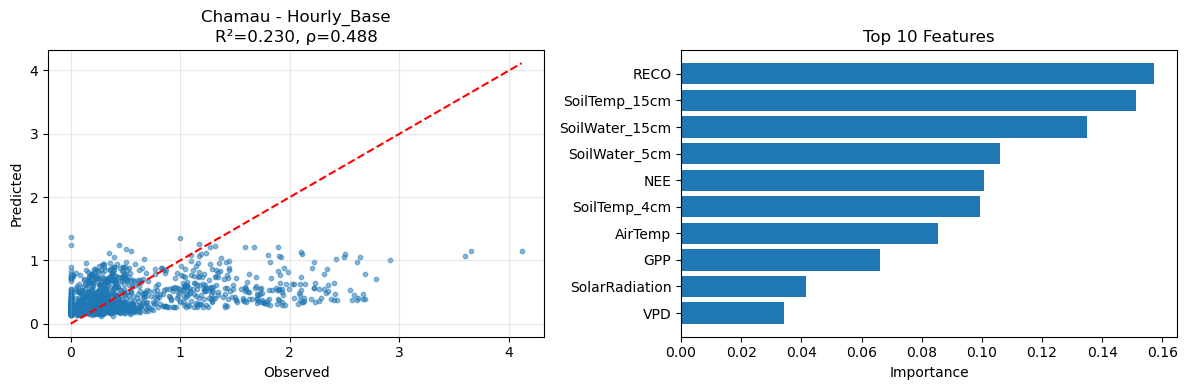


Hourly_Lag:


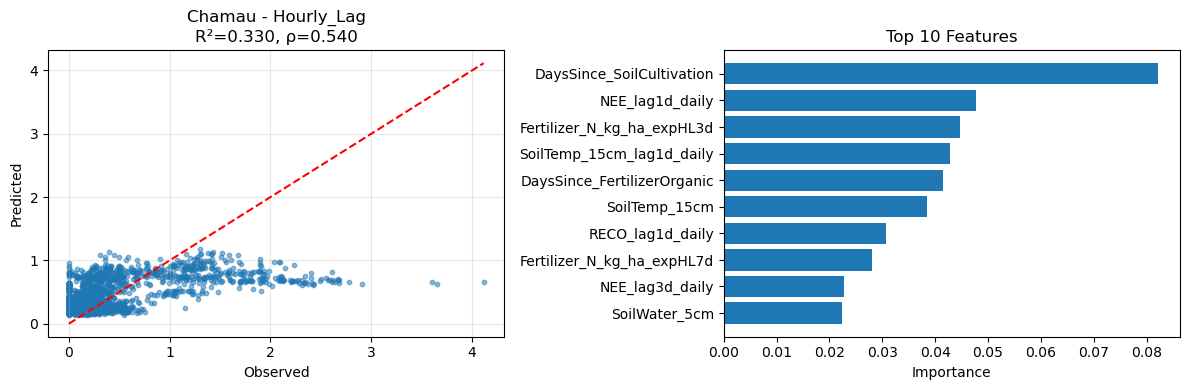


Hourly_Augmented:


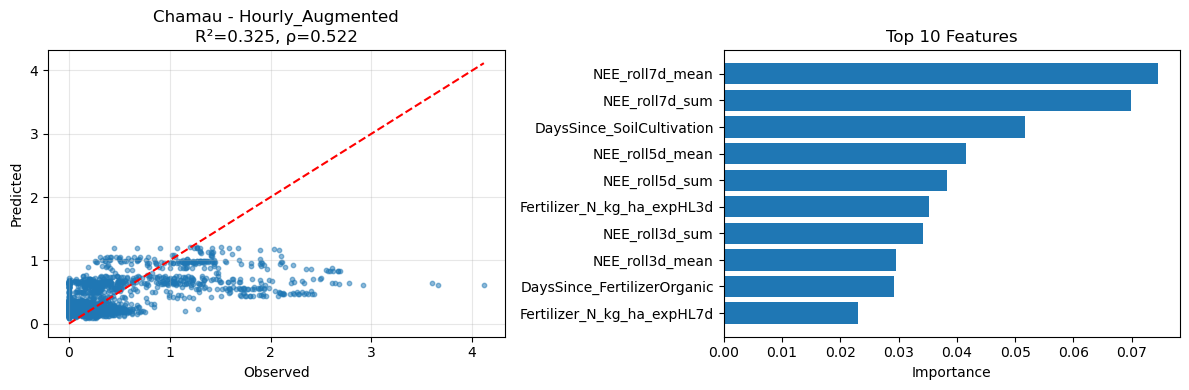


Daily_Base:


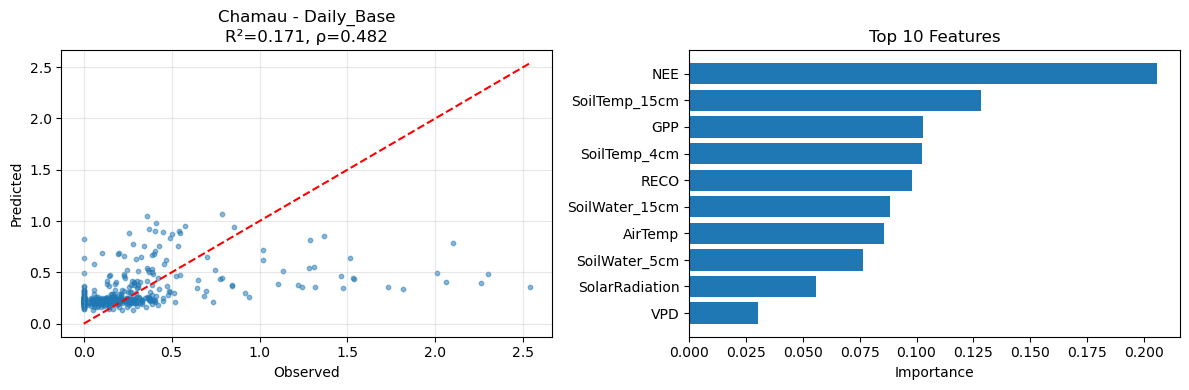


Daily_Lag:


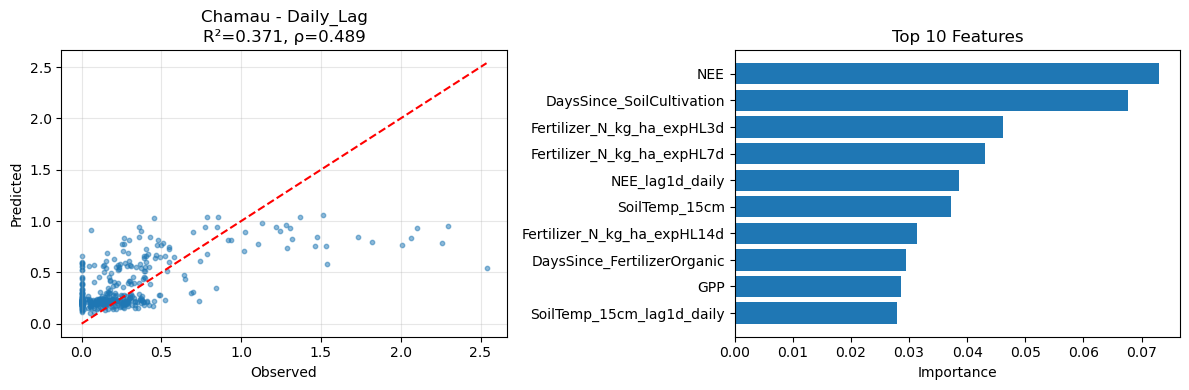


Daily_Augmented:


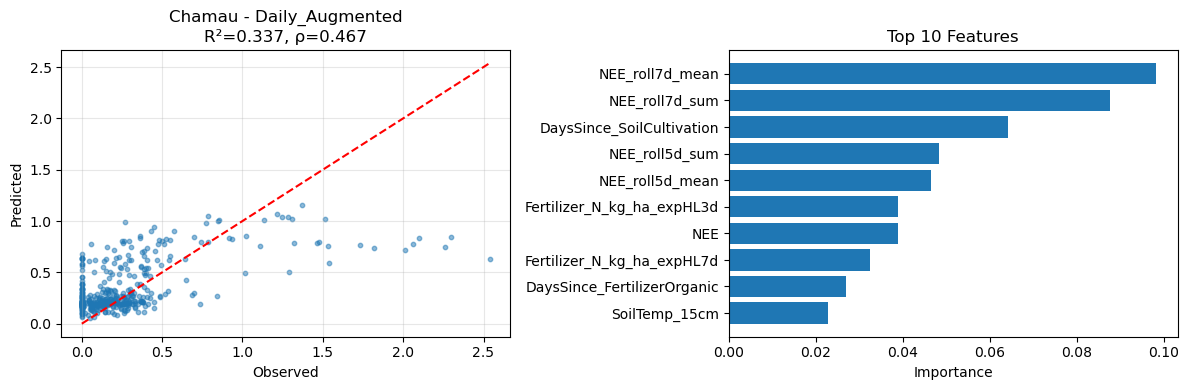

In [15]:
# Validate Chamau models
print("="*70)
print("VALIDATING CHAMAU MODELS")
print("="*70)

for exp_name, df, predictors in chamau_experiments:
    print(f"\n{exp_name}:")
    validate_rf_model(
        df=df,
        predictors=predictors,
        target=TARGET,
        params=chamau_rf_params[exp_name],
        name=f"Chamau - {exp_name}"
    )

VALIDATING OENSINGEN 2021-23 MODELS

Hourly_Base:


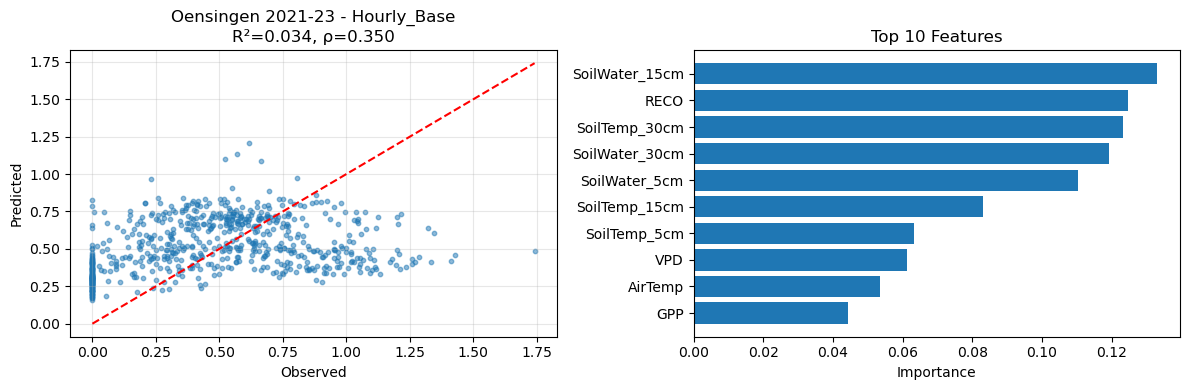


Hourly_Lag:


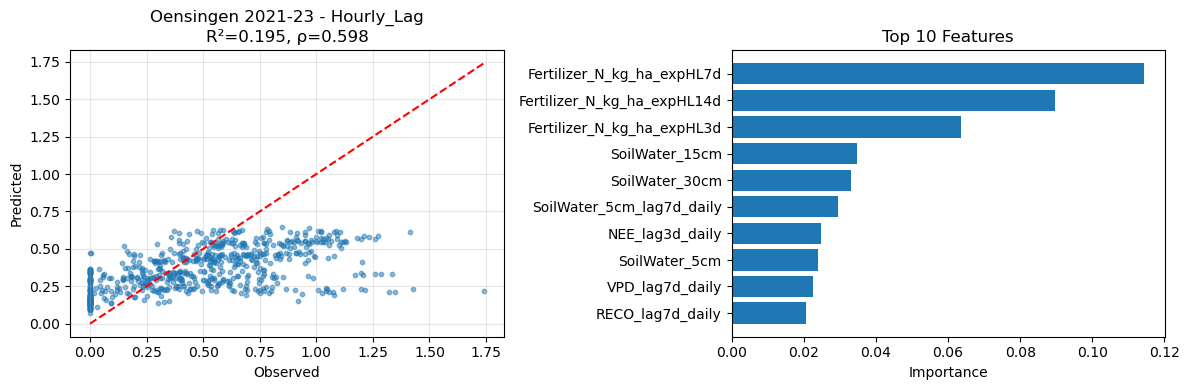


Hourly_Augmented:


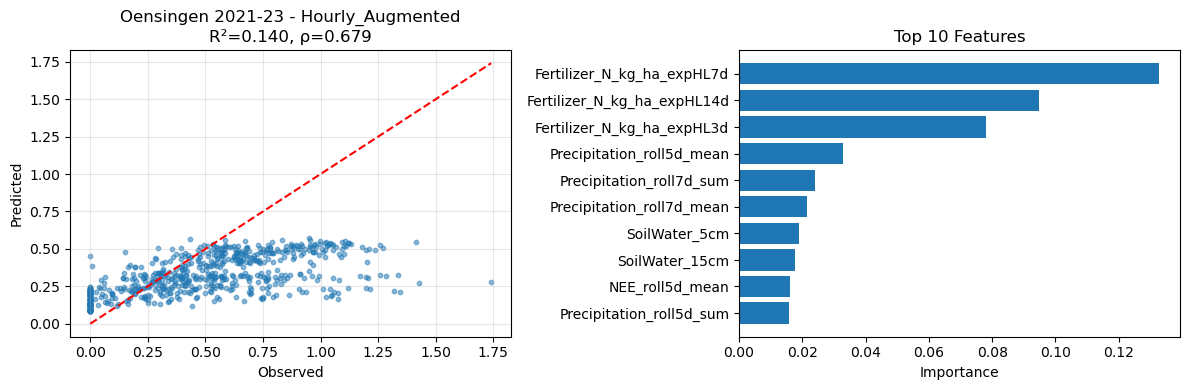


Daily_Base:


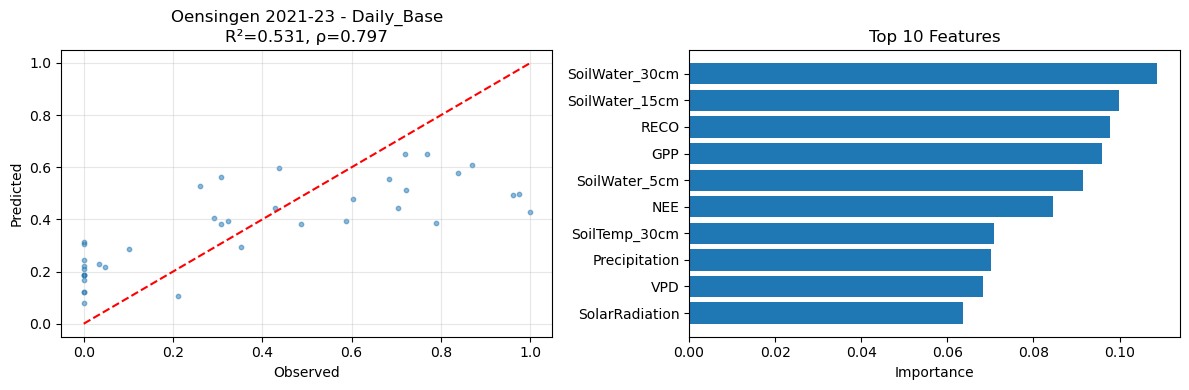


Daily_Lag:


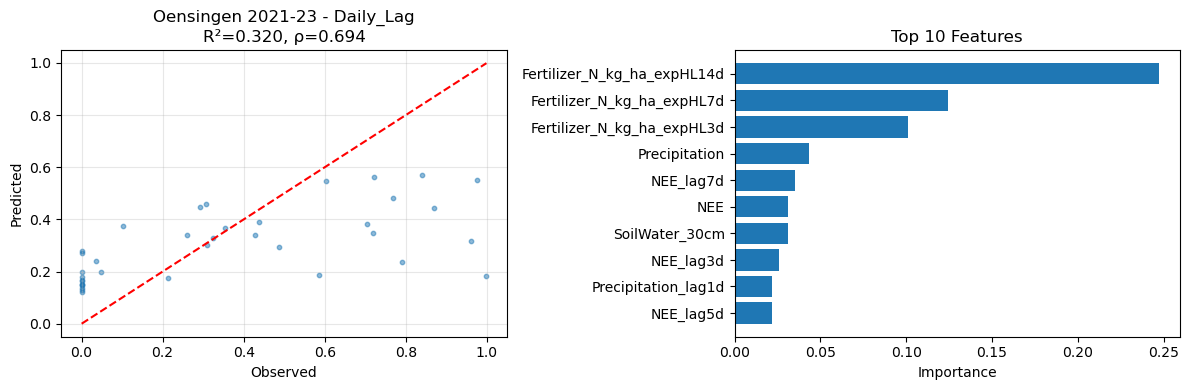


Daily_Augmented:


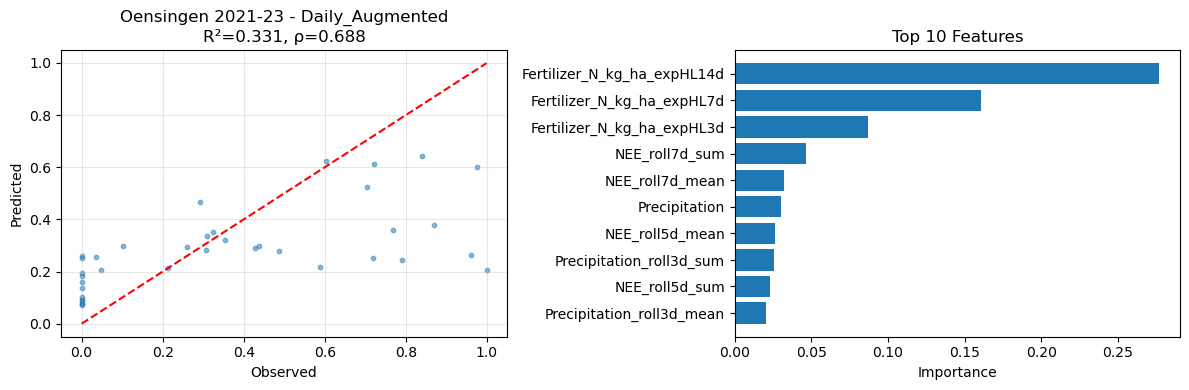

In [16]:
# Validate Oensingen models
print("="*70)
print("VALIDATING OENSINGEN 2021-23 MODELS")
print("="*70)

for exp_name, df, predictors in oensingen_experiments:
    print(f"\n{exp_name}:")
    validate_rf_model(
        df=df,
        predictors=predictors,
        target=TARGET,
        params=oensingen_rf_params[exp_name],
        name=f"Oensingen 2021-23 - {exp_name}"
    )

VALIDATING FOREL MODELS

Hourly_Base:


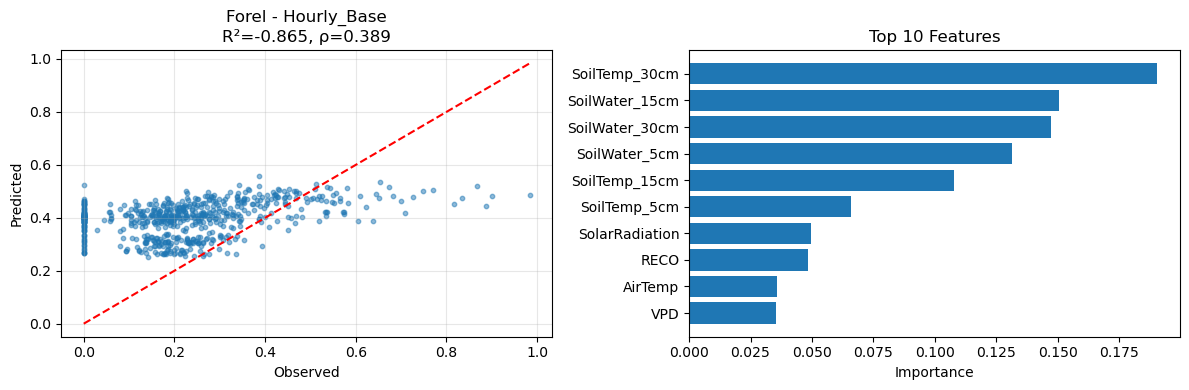


Hourly_Lag:


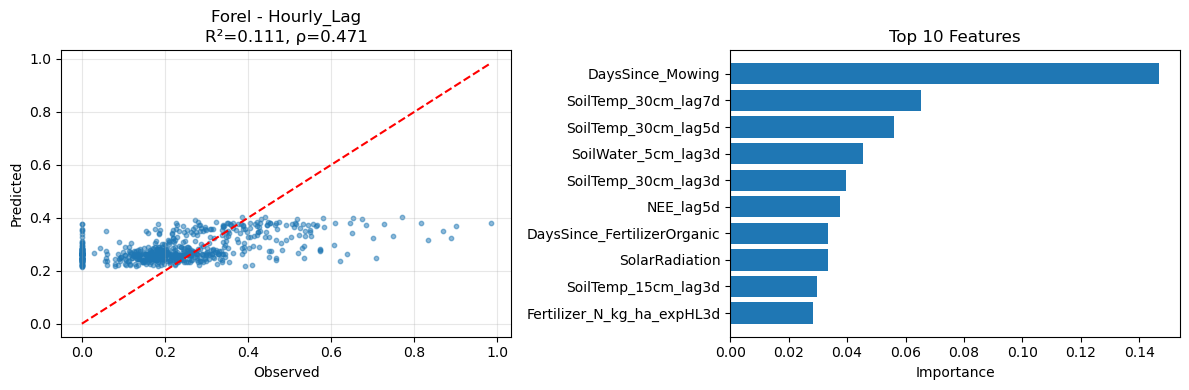


Hourly_Augmented:


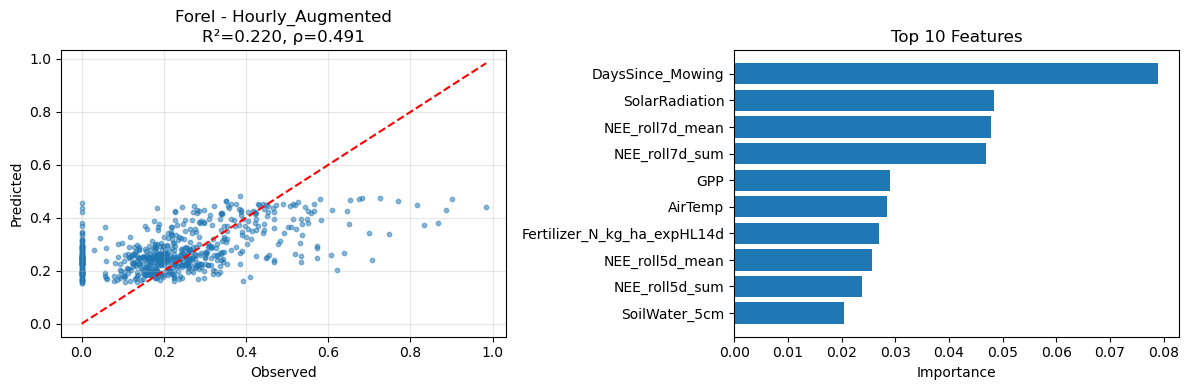


Daily_Base:


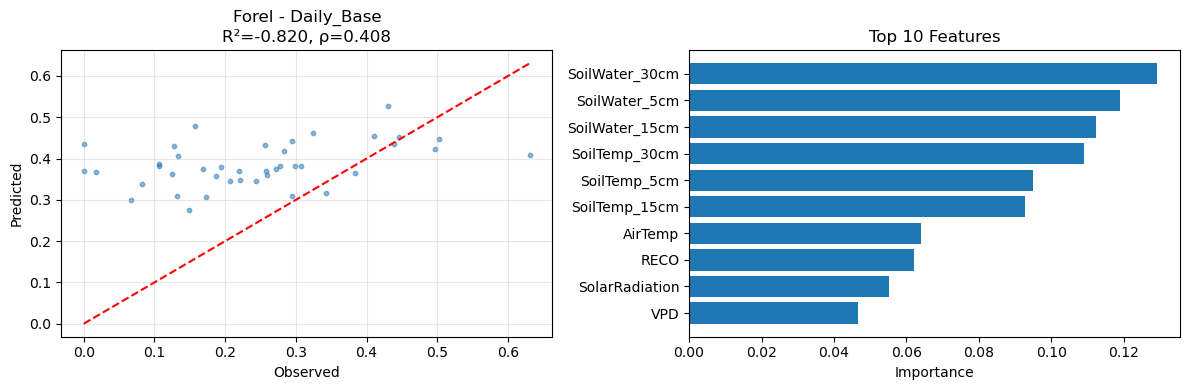


Daily_Lag:


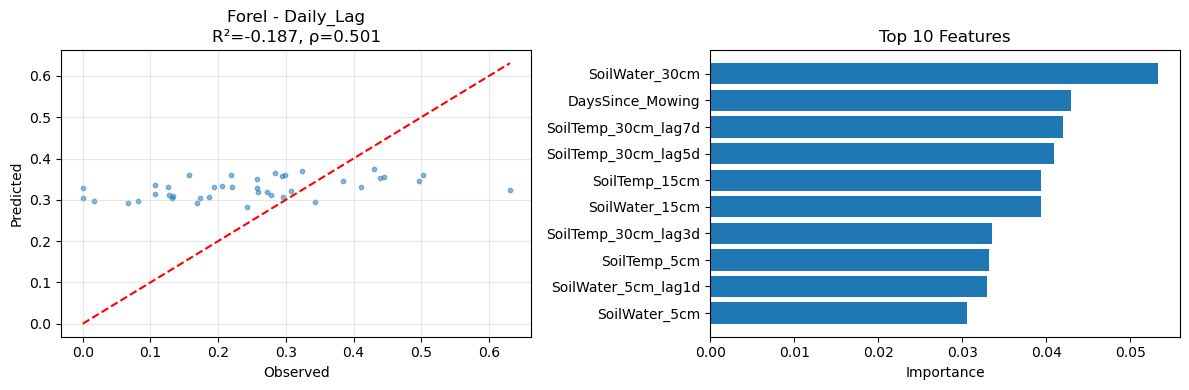


Daily_Augmented:


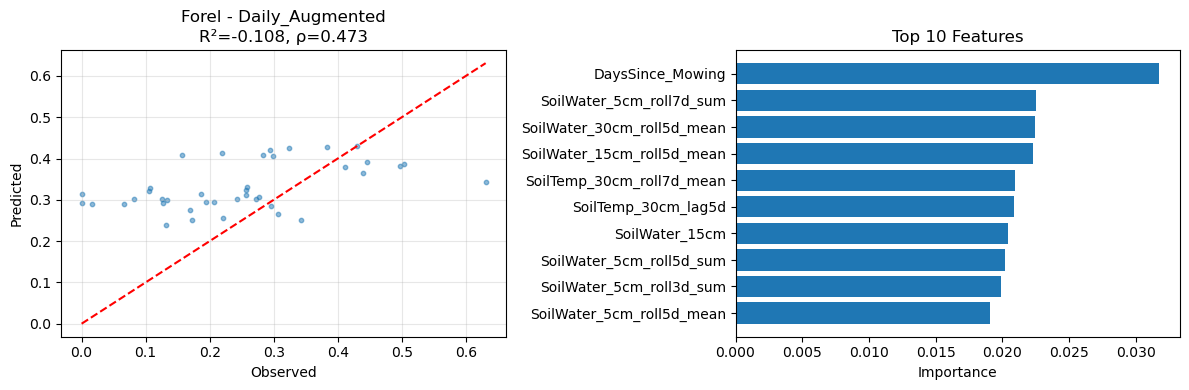

In [17]:
# Validate Forel models
print("="*70)
print("VALIDATING FOREL MODELS")
print("="*70)

for exp_name, df, predictors in forel_experiments:
    print(f"\n{exp_name}:")
    validate_rf_model(
        df=df,
        predictors=predictors,
        target=TARGET,
        params=forel_rf_params[exp_name],
        name=f"Forel - {exp_name}"
    )